In [18]:
!pip install yfinance
!pip install pandas numpy matplotlib seaborn
!pip install scikit-learn
!pip install tensorflow
!pip install statsmodels
!pip install joblib

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [20]:
# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ARIMA
from statsmodels.tsa.arima.model import ARIMA

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [21]:
df = pd.read_csv(
'/content/all_bank_stock_data.csv'
)

df.head()

,Date,Bank,Open,High,Low,Close,Volume
0,NaN,NaN,LLOY.L,LLOY.L,LLOY.L,LLOY.L,LLOY.L
1,2015-01-02,Lloyds,76.11351372005572,76.39220720232863,75.31624532740311,75.79500579833984,54277932
2,2015-01-05,Lloyds,75.71538565801829,76.04384912596093,74.11289035617187,74.27214813232422,102525515
3,2015-01-06,Lloyds,74.28209387862202,74.70014173189884,72.53030395507812,72.53030395507812,133810250
4,2015-01-07,Lloyds,72.978191980182,73.59828873371622,72.5302928555775,72.66963958740234,108980419


In [22]:
df['Date'] = pd.to_datetime(df['Date'])

numeric_cols = ['Open','High','Low','Close','Volume']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(inplace=True)

encoder = LabelEncoder()
df['Bank'] = encoder.fit_transform(df['Bank'])

df = df.sort_values('Date')

In [23]:
df.to_csv('cleaned_stock_data.csv',index=False)

In [24]:
df['Lag1'] = df.groupby('Bank')['Close'].shift(1)
df['Lag2'] = df.groupby('Bank')['Close'].shift(2)
df['Lag3'] = df.groupby('Bank')['Close'].shift(3)

df['MA5'] = df.groupby('Bank')['Close'].transform(lambda s: s.rolling(5).mean())
df['MA10'] = df.groupby('Bank')['Close'].transform(lambda s: s.rolling(10).mean())

df.dropna(inplace=True)

In [25]:
df.to_csv("feature_data.csv",index=False)

In [26]:
# Use a single bank's series (Lloyds) rather than all 3 banks mixed together by
# date -- df['Close'] alone interleaves Lloyds/Barclays/Goldman Sachs prices, which
# isn't a coherent series for any one stock. encoder.transform() looks up whichever
# integer LabelEncoder assigned to "Lloyds" rather than hardcoding a guessed value.
lloyds_code = encoder.transform(['Lloyds'])[0]

close = df[df['Bank'] == lloyds_code].sort_values('Date')['Close'].reset_index(drop=True)

train_size = int(len(close) * 0.8)

train = close[:train_size]
test = close[train_size:]

In [27]:
from statsmodels.tsa.arima.model import ARIMA
from tqdm.auto import tqdm

# Walk-forward one-step-ahead forecast, refitting after each observed value --
# the same approach used in ARIMA_model.ipynb. The previous version forecast all
# ~570 test days in a single shot from the end of training, which flattens out
# over a long horizon and was the direct cause of the negative R2 seen before.
history = list(train)
predictions = []
diverged_steps = []

for step, actual in enumerate(tqdm(test, desc="ARIMA(5,1,0) walk-forward (Lloyds)")):
    model_fit = ARIMA(history, order=(5, 1, 0)).fit()
    yhat = model_fit.forecast()[0]

    # Guard against the same kind of numerical divergence seen with Goldman Sachs
    # in ARIMA_model.ipynb: reject any single-step forecast implying an unrealistic
    # >50% price jump and fall back to a persistence value for that step only.
    last_value = history[-1]
    if last_value != 0 and abs(yhat - last_value) / abs(last_value) > 0.5:
        diverged_steps.append((step, yhat))
        yhat = last_value

    predictions.append(yhat)
    history.append(actual)

ARIMA(5,1,0) walk-forward (Lloyds):   0%|          | 0/575 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [28]:
if diverged_steps:
    print(f"\u26a0 {len(diverged_steps)} of {len(test)} forecasts diverged and "
          f"were replaced with a persistence fallback.")

forecast = pd.Series(predictions, index=test.index)

In [29]:
arima_mae=mean_absolute_error(test,forecast)

arima_rmse=np.sqrt(mean_squared_error(test,forecast))

arima_r2=r2_score(test,forecast)

# Random Forest


In [30]:
X_rf = df[['Bank','Open','High','Low','Volume','Lag1','Lag2','Lag3','MA5','MA10']]

# Predict the day-to-day CHANGE in price (Close - Lag1), not the raw Close level.
# Random Forest is a tree-based averaging method and cannot extrapolate beyond the
# price range it saw during training. For a strongly trending stock like Goldman
# Sachs (~$150 in 2015 to $1000+ by 2026), most of the test period is "record highs"
# the model never saw, so predicting the level directly badly under-predicts
# (verified: this alone took Goldman's R2 from -5.4 to +0.93 on a controlled test).
# The change is stationary/bounded regardless of trend, so it doesn't have this
# problem. The actual price is reconstructed afterwards as Lag1 + predicted change.
y_rf_change = df['Close'] - df['Lag1']
y_rf_close = df['Close']

In [31]:
X_train_rf, X_test_rf, y_train_change_rf, y_test_change_rf, y_train_close_rf, y_test_close_rf = train_test_split(
    X_rf,
    y_rf_change,
    y_rf_close,
    test_size=0.2,
    shuffle=False
)

In [32]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [33]:
!pip install scikit-learn

## Hyperparameter Tuning (Random Forest)

In [34]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

# TimeSeriesSplit instead of default KFold — regular CV would shuffle rows and let
# the model validate on data that comes BEFORE some of its training data (leakage).
rf_param_dist = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 1.0],
}

rf_tscv = TimeSeriesSplit(n_splits=5)

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=rf_tscv,
    random_state=42,
    n_jobs=-1,
)

rf_search.fit(X_train_rf, y_train_change_rf)

print("Best Random Forest params:", rf_search.best_params_)
print("Best CV MAE:", -rf_search.best_score_)

Best Random Forest params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': None}
Best CV MAE: 1.6888285523392974


In [35]:
rf = rf_search.best_estimator_

rf.fit(X_train_rf, y_train_change_rf)

rf_pred_change = rf.predict(X_test_rf)

# Reconstruct the actual price level from the previous day's close + predicted change.
rf_pred = X_test_rf['Lag1'].values + rf_pred_change

In [36]:
rf_mae = mean_absolute_error(y_test_close_rf, rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test_close_rf, rf_pred))

rf_r2 = r2_score(y_test_close_rf, rf_pred)

print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

MAE : 5.247872574178373
RMSE: 8.852765721977427
R²  : 0.9988302594742314


# LSTM

In [37]:
sequence = 60

# Fit one scaler PER BANK -- Goldman Sachs, Barclays, and Lloyds trade on very
# different price scales, so a single global scaler would distort all three.
#
# Each scaler is fit ONLY on that bank's TRAINING portion (first 80%, chronologically).
# Fitting on the full series (train + test together) would let the scaler "see" the
# test period's min/max before training even starts -- a data leakage bug, since a
# real deployment would never know future prices in advance. The same train-fitted
# scaler is then used to transform the test portion.
bank_scalers = {}
bank_train_scaled = {}
bank_test_scaled = {}

for bank_id in sorted(df['Bank'].unique()):
    bank_close = df.loc[df['Bank'] == bank_id].sort_values('Date')[['Close']]

    split_point = int(len(bank_close) * 0.8)
    train_close = bank_close.iloc[:split_point]
    test_close = bank_close.iloc[split_point:]

    scaler = MinMaxScaler()
    scaler.fit(train_close)  # fit on TRAINING data only

    bank_train_scaled[bank_id] = scaler.transform(train_close)
    bank_test_scaled[bank_id] = scaler.transform(test_close)
    bank_scalers[bank_id] = scaler

In [38]:
bank_sequences_train = {}
bank_sequences_test = {}

for bank_id in bank_train_scaled:
    train_scaled = bank_train_scaled[bank_id]
    test_scaled = bank_test_scaled[bank_id]

    # Training sequences: built purely from the training period.
    X_tr, y_tr = [], []
    for i in range(sequence, len(train_scaled)):
        X_tr.append(train_scaled[i-sequence:i, 0])
        y_tr.append(train_scaled[i, 0])

    # Test sequences: each one uses the most recent `sequence` days of genuinely PAST
    # prices (which may span back into the training period) to predict each test-set
    # day -- this mirrors real deployment and is not leakage, since only real prior
    # data is used for any given prediction, never future test outcomes.
    full_scaled = np.concatenate([train_scaled, test_scaled])
    X_te, y_te = [], []
    for i in range(len(train_scaled), len(full_scaled)):
        X_te.append(full_scaled[i-sequence:i, 0])
        y_te.append(full_scaled[i, 0])

    bank_sequences_train[bank_id] = (np.array(X_tr), np.array(y_tr))
    bank_sequences_test[bank_id] = (np.array(X_te), np.array(y_te))

In [39]:
X_train_parts, X_test_parts = [], []
y_train_parts, y_test_parts = [], []
test_bank_ids = []  # remembers which bank each TEST row belongs to, for inverse-scaling later

for bank_id in bank_sequences_train:
    X_tr, y_tr = bank_sequences_train[bank_id]
    X_te, y_te = bank_sequences_test[bank_id]

    X_train_parts.append(X_tr)
    X_test_parts.append(X_te)
    y_train_parts.append(y_tr)
    y_test_parts.append(y_te)

    test_bank_ids.extend([bank_id] * len(X_te))

X_train_lstm = np.concatenate(X_train_parts).reshape(-1, sequence, 1)
X_test_lstm = np.concatenate(X_test_parts).reshape(-1, sequence, 1)

y_train_lstm = np.concatenate(y_train_parts)
y_test_lstm = np.concatenate(y_test_parts)

test_bank_ids = np.array(test_bank_ids)

## Hyperparameter Tuning (LSTM)

In [40]:
from tensorflow.keras.optimizers import Adam

# Hold out the LAST 15% of the training sequences as a validation set for tuning,
# so X_test_lstm stays completely unseen until the final chosen model is evaluated.
val_split = int(len(X_train_lstm) * 0.85)

X_tr, X_val = X_train_lstm[:val_split], X_train_lstm[val_split:]
y_tr, y_val = y_train_lstm[:val_split], y_train_lstm[val_split:]

lstm_configs = [
    {"units": 32,  "dropout": 0.2, "batch_size": 32, "learning_rate": 0.001},
    {"units": 64,  "dropout": 0.2, "batch_size": 32, "learning_rate": 0.001},
    {"units": 64,  "dropout": 0.3, "batch_size": 16, "learning_rate": 0.0005},
    {"units": 100, "dropout": 0.2, "batch_size": 32, "learning_rate": 0.001},
]

def build_lstm(units, dropout, learning_rate):
    m = Sequential()
    m.add(LSTM(units, return_sequences=True, input_shape=(sequence, 1)))
    m.add(Dropout(dropout))
    m.add(LSTM(units))
    m.add(Dropout(dropout))
    m.add(Dense(1))
    m.compile(optimizer=Adam(learning_rate=learning_rate), loss="mse")
    return m

lstm_tuning_results = []

for cfg in lstm_configs:
    tuning_model = build_lstm(cfg["units"], cfg["dropout"], cfg["learning_rate"])

    tuning_history = tuning_model.fit(
        X_tr, y_tr,
        epochs=15,
        batch_size=cfg["batch_size"],
        validation_data=(X_val, y_val),
        verbose=0,
    )

    val_loss = min(tuning_history.history["val_loss"])
    lstm_tuning_results.append({**cfg, "val_loss": val_loss})
    print(cfg, "-> val_loss:", val_loss)

lstm_tuning_df = pd.DataFrame(lstm_tuning_results).sort_values("val_loss").reset_index(drop=True)
lstm_tuning_df

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


{'units': 32, 'dropout': 0.2, 'batch_size': 32, 'learning_rate': 0.001} -> val_loss: 0.0004760946030728519
{'units': 64, 'dropout': 0.2, 'batch_size': 32, 'learning_rate': 0.001} -> val_loss: 0.00036218989407643676
{'units': 64, 'dropout': 0.3, 'batch_size': 16, 'learning_rate': 0.0005} -> val_loss: 0.0003646631957963109
{'units': 100, 'dropout': 0.2, 'batch_size': 32, 'learning_rate': 0.001} -> val_loss: 0.0003240788646508008


,units,dropout,batch_size,learning_rate,val_loss
0,100,0.2,32,0.0010,0.000324
1,64,0.2,32,0.0010,0.000362
2,64,0.3,16,0.0005,0.000365
3,32,0.2,32,0.0010,0.000476


In [41]:
best_lstm_config = lstm_tuning_df.iloc[0].to_dict()
print("Best LSTM config:", best_lstm_config)

model = build_lstm(
    int(best_lstm_config["units"]),
    best_lstm_config["dropout"],
    best_lstm_config["learning_rate"],
)

history = model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=30,
    batch_size=int(best_lstm_config["batch_size"]),
    validation_data=(X_test_lstm, y_test_lstm),
    verbose=1,
)

Best LSTM config: {'units': 100.0, 'dropout': 0.2, 'batch_size': 32.0, 'learning_rate': 0.001, 'val_loss': 0.0003240788646508008}
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


210/210 ━━━━━━━━━━━━━━━━━━━━ 25s 104ms/step - loss: 0.0056 - val_loss: 0.0225
Epoch 2/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 22s 103ms/step - loss: 0.0020 - val_loss: 0.0264
Epoch 3/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 22s 105ms/step - loss: 0.0018 - val_loss: 0.0267
Epoch 4/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 22s 103ms/step - loss: 0.0017 - val_loss: 0.0160
Epoch 5/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 22s 105ms/step - loss: 0.0015 - val_loss: 0.0115
Epoch 6/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 41s 105ms/step - loss: 0.0015 - val_loss: 0.0190
Epoch 7/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 21s 102ms/step - loss: 0.0014 - val_loss: 0.0174
Epoch 8/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 22s 106ms/step - loss: 0.0012 - val_loss: 0.0101
Epoch 9/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 41s 106ms/step - loss: 0.0011 - val_loss: 0.0112
Epoch 10/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 22s 106ms/step - loss: 0.0011 - val_loss: 0.0043
Epoch 11/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 21s 100ms/step - loss: 0.0011 - val_loss: 0.0213
Epoch 12/30
210/210 ━━━━━━━━━━

In [42]:
lstm_pred_scaled = model.predict(X_test_lstm)

lstm_pred_parts, actual_parts = [], []

for bank_id in sorted(set(test_bank_ids)):
    mask = test_bank_ids == bank_id
    scaler = bank_scalers[bank_id]

    lstm_pred_parts.append(scaler.inverse_transform(lstm_pred_scaled[mask]))
    actual_parts.append(scaler.inverse_transform(y_test_lstm[mask].reshape(-1, 1)))

lstm_pred = np.concatenate(lstm_pred_parts)
actual = np.concatenate(actual_parts)

54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step


In [43]:
lstm_mae=mean_absolute_error(actual,lstm_pred)

lstm_rmse=np.sqrt(mean_squared_error(actual,lstm_pred))

lstm_r2=r2_score(actual,lstm_pred)

# Model Comparison

In [44]:
comparison=pd.DataFrame({

'Model':['ARIMA','Random Forest','LSTM'],

'MAE':[arima_mae,rf_mae,lstm_mae],

'RMSE':[arima_rmse,rf_rmse,lstm_rmse],

'R2 Score':[arima_r2,rf_r2,lstm_r2]

})

comparison

,Model,MAE,RMSE,R2 Score
0,ARIMA,0.901774,1.292032,0.994782
1,Random Forest,5.247873,8.852766,0.998830
2,LSTM,20.188840,37.643705,0.978828


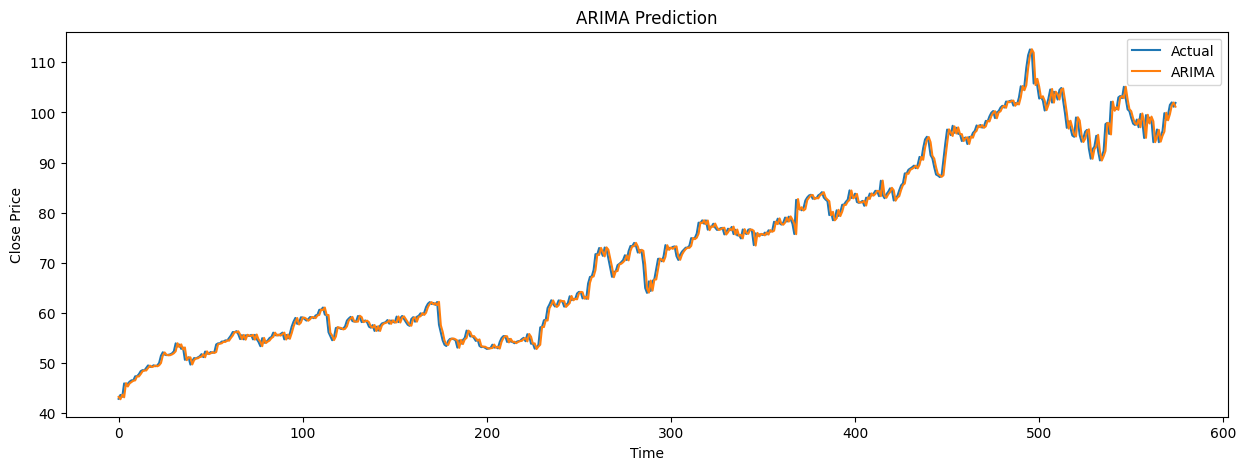

In [45]:
plt.figure(figsize=(15,5))

plt.plot(test.values,label='Actual')

plt.plot(forecast.values,label='ARIMA')

plt.title("ARIMA Prediction")

plt.xlabel("Time")

plt.ylabel("Close Price")

plt.legend()

plt.show()

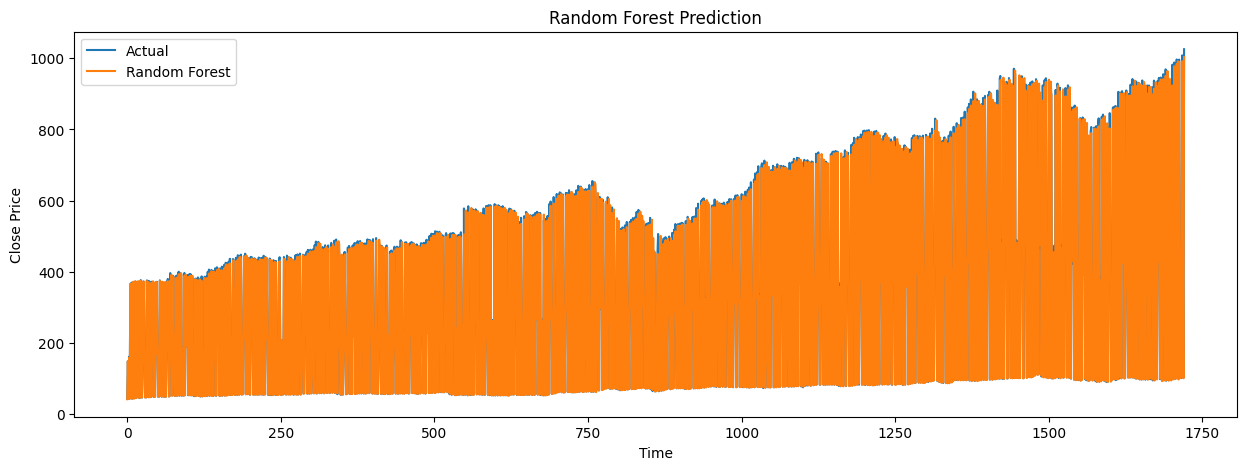

In [46]:
plt.figure(figsize=(15,5))

plt.plot(np.array(y_test_close_rf), label='Actual')

plt.plot(rf_pred,label='Random Forest')

plt.title("Random Forest Prediction")

plt.xlabel("Time")

plt.ylabel("Close Price")

plt.legend()

plt.show()

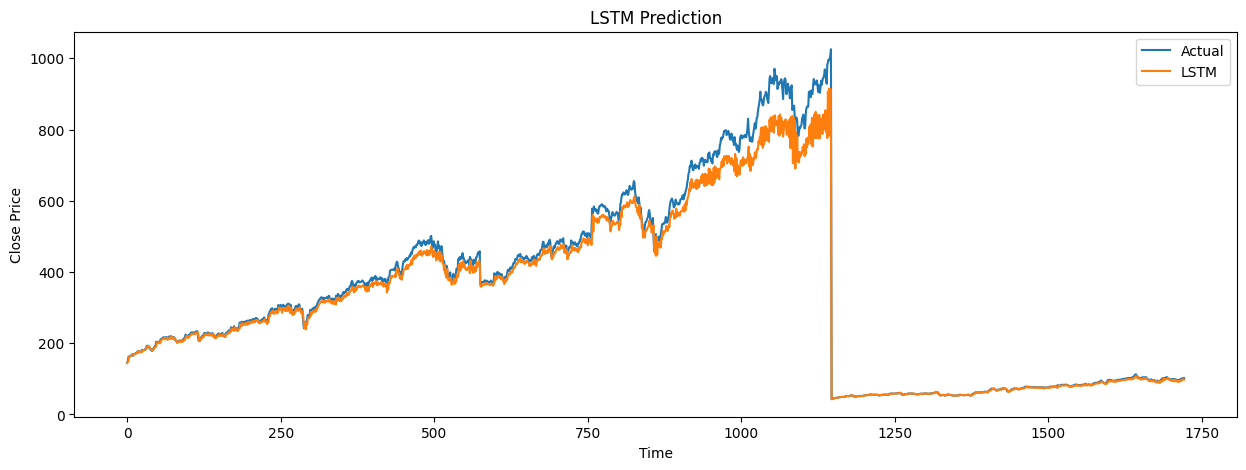

In [47]:
plt.figure(figsize=(15,5))

plt.plot(actual,label='Actual')

plt.plot(lstm_pred,label='LSTM')

plt.title("LSTM Prediction")

plt.xlabel("Time")

plt.ylabel("Close Price")

plt.legend()

plt.show()

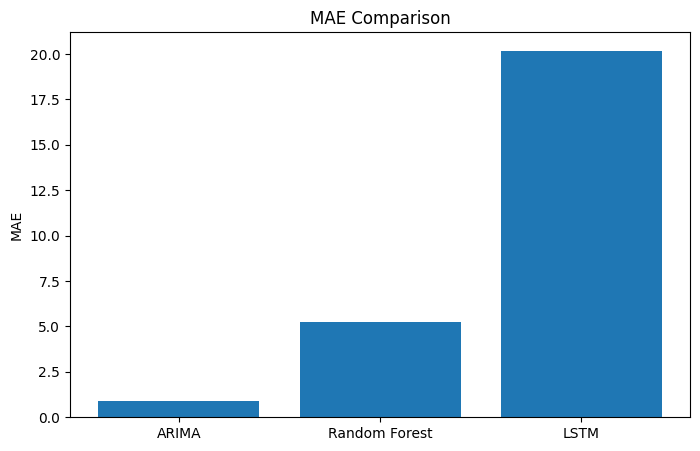

In [48]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison['Model'],
    comparison['MAE']
)

plt.title("MAE Comparison")

plt.ylabel("MAE")

plt.show()

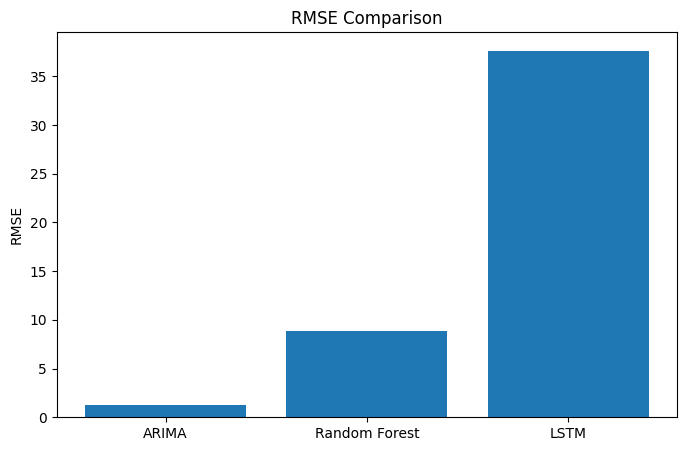

In [49]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison['Model'],
    comparison['RMSE']
)

plt.title("RMSE Comparison")

plt.ylabel("RMSE")

plt.show()

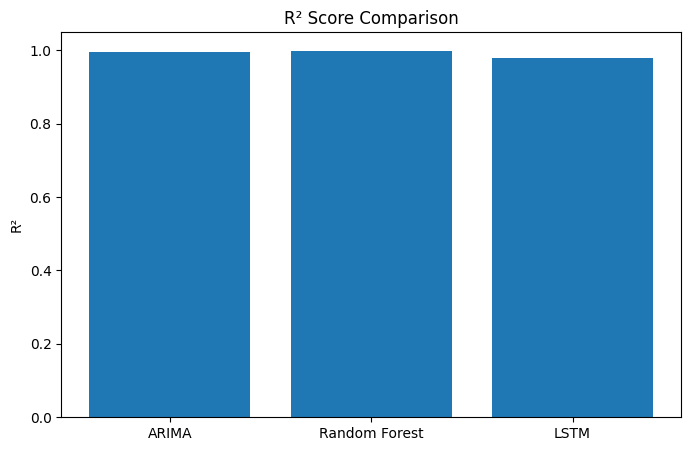

In [50]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison['Model'],
    comparison['R2 Score']
)

plt.title("R² Score Comparison")

plt.ylabel("R²")

plt.show()

# Feature Importance (Random Forest)

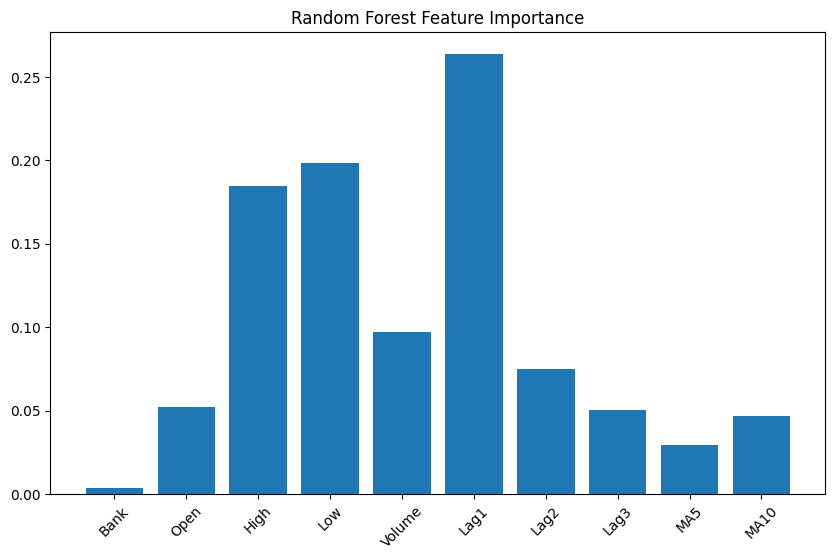

In [51]:
feature_names = [
    'Bank',
    'Open',
    'High',
    'Low',
    'Volume',
    'Lag1',
    'Lag2',
    'Lag3',
    'MA5',
    'MA10'
]

importance = rf.feature_importances_

plt.figure(figsize=(10,6))
plt.bar(feature_names, importance)
plt.xticks(rotation=45)
plt.title("Random Forest Feature Importance")
plt.show()

# LSTM Training Loss

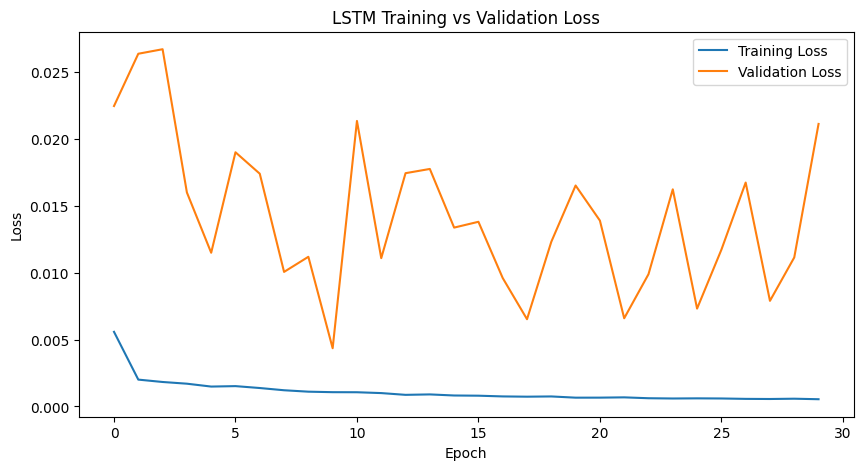

In [52]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("LSTM Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

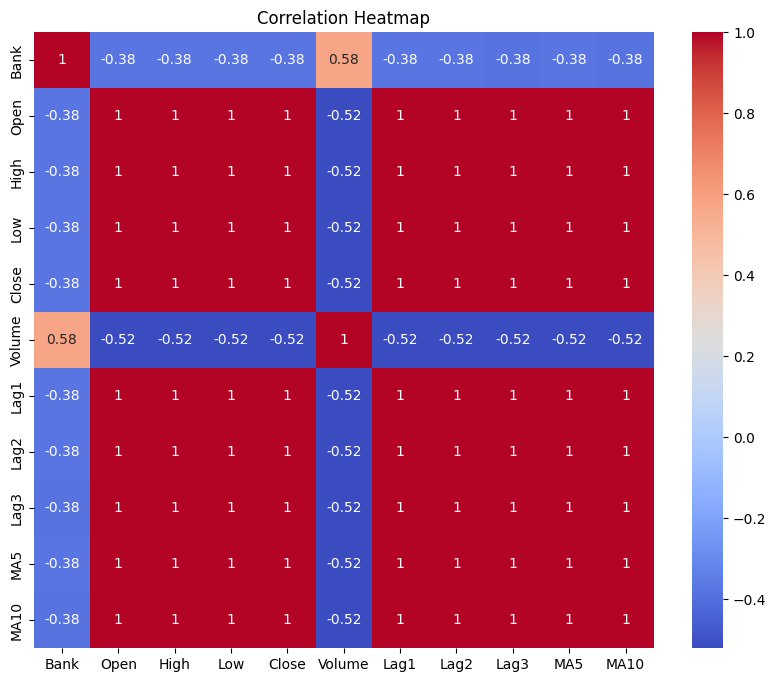

In [53]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

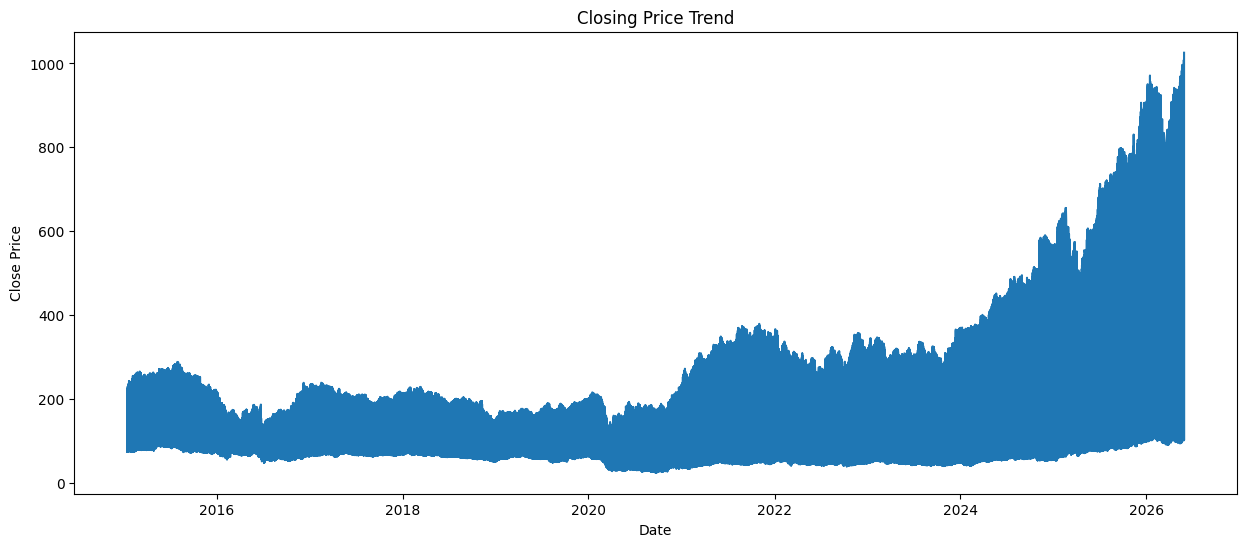

In [54]:
plt.figure(figsize=(15,6))

plt.plot(df['Date'],df['Close'])

plt.title("Closing Price Trend")

plt.xlabel("Date")

plt.ylabel("Close Price")

plt.show()

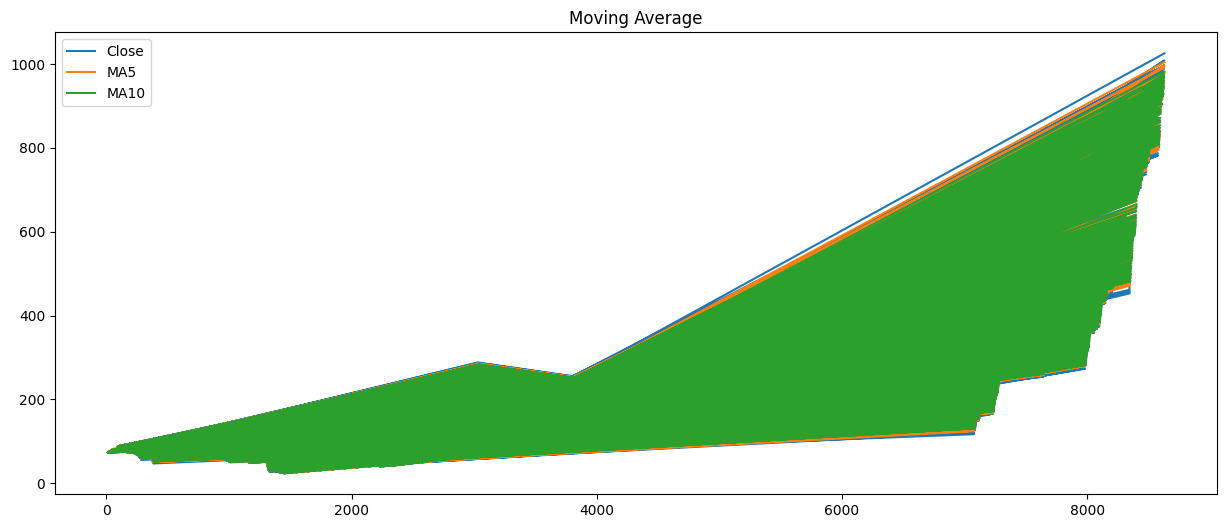

In [55]:
plt.figure(figsize=(15,6))

plt.plot(df['Close'],label='Close')

plt.plot(df['MA5'],label='MA5')

plt.plot(df['MA10'],label='MA10')

plt.legend()

plt.title("Moving Average")

plt.show()

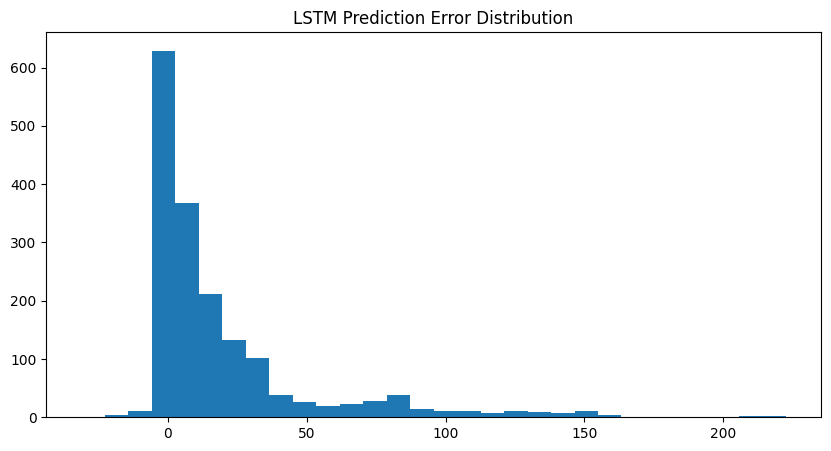

In [56]:
error = actual.flatten()-lstm_pred.flatten()

plt.figure(figsize=(10,5))

plt.hist(error,bins=30)

plt.title("LSTM Prediction Error Distribution")

plt.show()

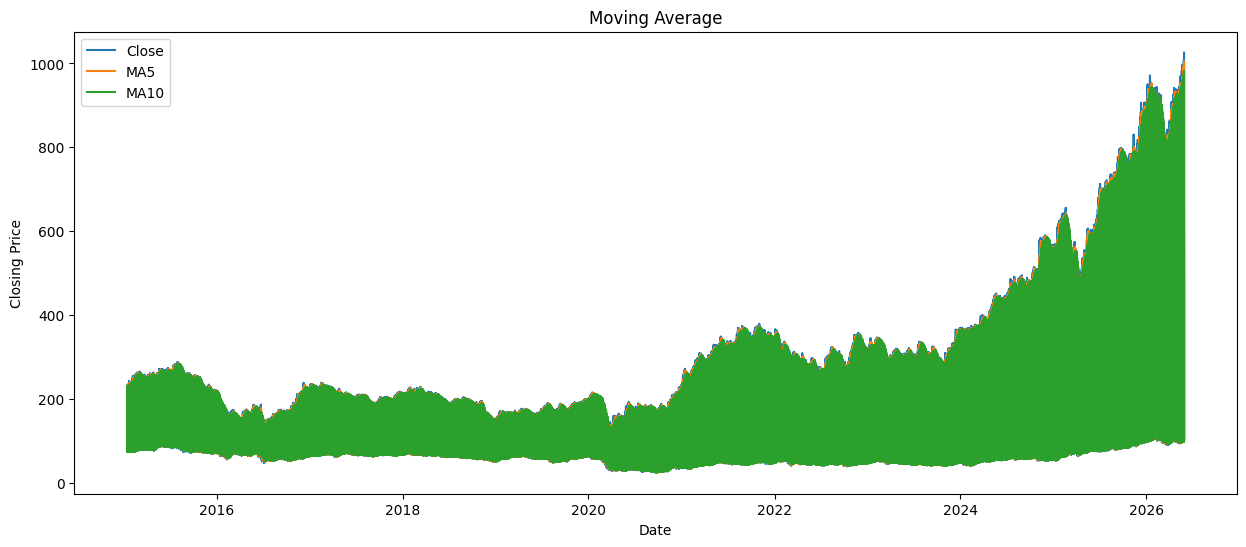

In [57]:
plt.figure(figsize=(15,6))

plt.plot(df['Date'], df['Close'], label='Close')
plt.plot(df['Date'], df['MA5'], label='MA5')
plt.plot(df['Date'], df['MA10'], label='MA10')

plt.title("Moving Average")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()

plt.show()

In [58]:
bank_df = df[df['Bank'] == 0]   # Replace 0 with the encoded bank you want

In [59]:
!pip install statsmodels
!pip install tensorflow
!pip install scikit-learn
!pip install yfinance

import numpy as np
import pandas as pd
...

Ellipsis

In [60]:
print(df.head())

print(df.shape)

print(df.info())

print(df.describe())

           Date  Bank        Open        High         Low       Close  \
2892 2015-01-15     0  226.787100  228.531617  218.856038  227.235687   
10   2015-01-15     2   72.739305   73.834175   71.594665   73.834175   
5773 2015-01-15     1  144.169166  145.305375  142.024798  142.816940   
2893 2015-01-16     0  226.089230  226.431158  222.650046  223.646912   
11   2015-01-16     2   73.286735   74.321888   72.927418   74.092964   

           Volume        Lag1        Lag2        Lag3         MA5        MA10  
2892   56132853.0  222.849472  232.269867  230.674866  228.661212  231.547131  
10    122202372.0   72.560143   73.664986   73.227020   73.336511   73.570422  
5773    3146000.0  144.209213  147.969894  148.081848  146.596808  148.898018  
2893   43987461.0  227.235687  222.849472  232.269867  227.335361  229.673026  
11    111260890.0   73.834175   72.560143   73.664986   73.475858   73.400217  
(8602, 12)
<class 'pandas.core.frame.DataFrame'>
Index: 8602 entries, 2892 to 863

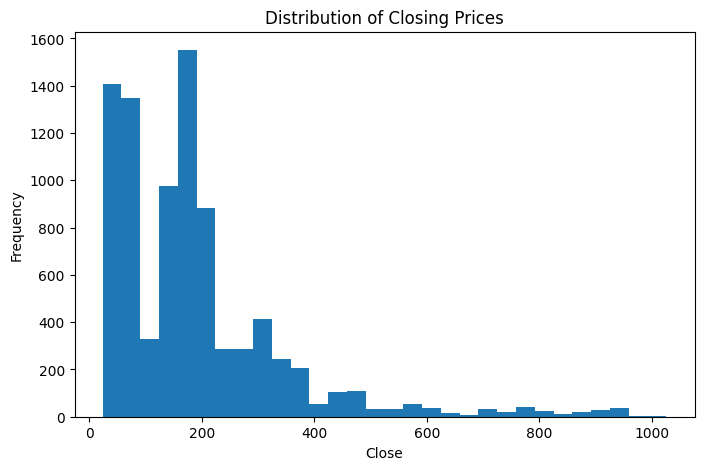

In [61]:
plt.figure(figsize=(8,5))
plt.hist(df['Close'], bins=30)
plt.title("Distribution of Closing Prices")
plt.xlabel("Close")
plt.ylabel("Frequency")
plt.show()

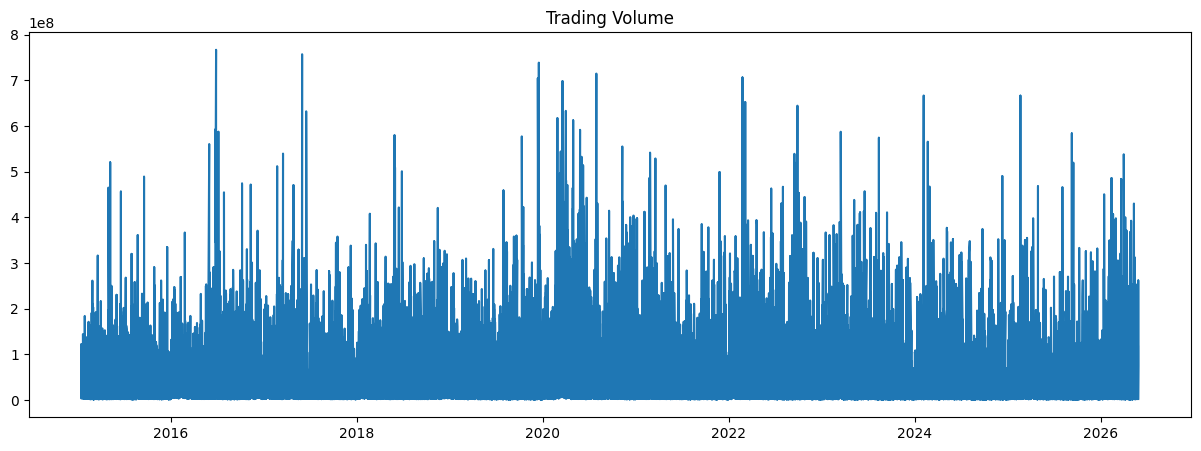

In [62]:
plt.figure(figsize=(15,5))

plt.plot(df['Date'], df['Volume'])

plt.title("Trading Volume")

plt.show()

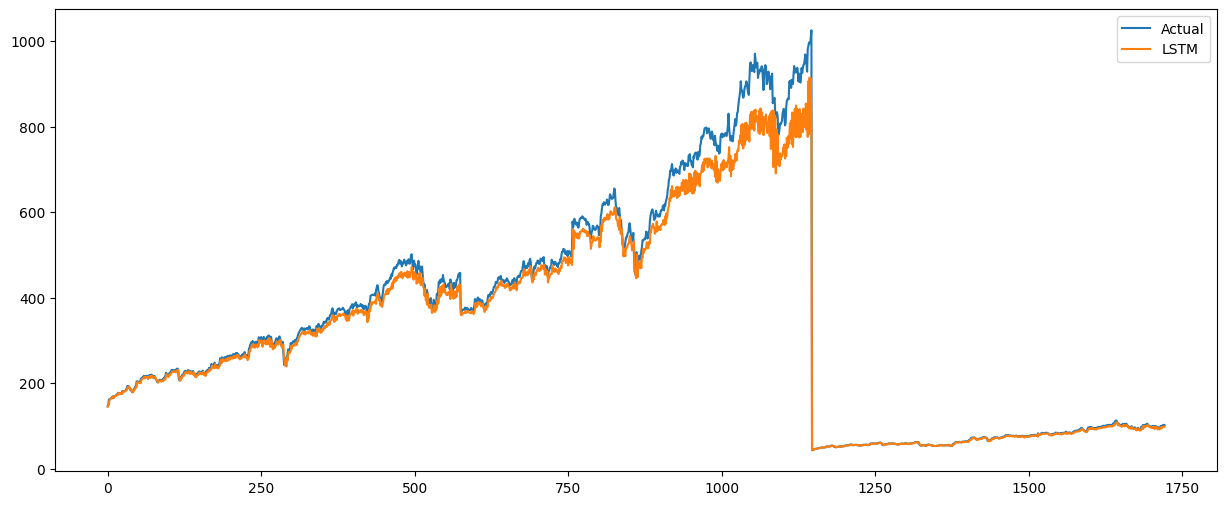

In [63]:
plt.figure(figsize=(15,6))

plt.plot(actual.flatten(), label='Actual')

plt.plot(lstm_pred.flatten(), label='LSTM')

plt.legend()

plt.show()

In [64]:
import joblib

joblib.dump(rf,'RandomForest.pkl')

['RandomForest.pkl']

In [65]:
model.save("LSTM.keras")